In [ ]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, TensorDataset, Dataset
from multi_unet_model_V2 import multi_unet_model1
import numpy as np
import sys
import glob
import os
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.patches as patches
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random

np.set_printoptions(threshold=sys.maxsize)

In [ ]:
#loading data and sizes
x_data_path = r'D:\images'
y_data_path = r'D:\masks'

SIZE_X = 240
SIZE_Y = 512
n_classes = 12
BATCH_SIZE = 16
EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
for directory_path in glob.glob(x_data_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        print(img_path)

D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_005.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_018.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_036.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_051.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_079.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_102.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_117.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_139.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_159.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_178.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_194.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OD_bscan_223.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OS_bscan_000.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OS_bscan_018.png
D:\Segmentation\output_cirrus\images\PSNASERI0802_OS_bscan_039

train_images.shape (1169, 512, 240, 1)
<class 'numpy.ndarray'>


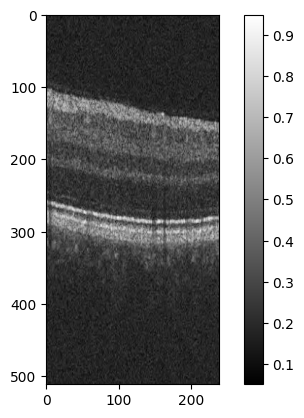

In [ ]:
#prepare training x (original) images
train_x_images = []

for directory_path in glob.glob(x_data_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_X, SIZE_Y))
        train_x_images.append(img)

train_x_images = np.array(train_x_images, dtype=np.float32)   #using float32 for PyTorch
train_x_images = train_x_images / 255.0
train_x_images = np.expand_dims(train_x_images, axis=-1)

print("train_images.shape", train_x_images.shape)
print(type(train_x_images))

plt.imshow(train_x_images[0], cmap='gray')
plt.colorbar()

In [ ]:
#loading and checking y (masks) data
train_y_images = []

for directory_path in glob.glob(y_data_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_X, SIZE_Y))
        train_y_images.append(img)

#cleaning masks for better training
cleaned_masks = []

for mask in train_y_images:
    mask = mask.squeeze()
    kernel = np.ones((3,3), np.uint8)

    # Remove small isolated pixels
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Fill small holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # smooth boundaries
    mask = cv2.dilate(mask, kernel, iterations=1)
    mask = cv2.erode(mask, kernel, iterations=1)

    cleaned_masks.append(mask)

train_y_images = np.array(cleaned_masks, dtype=np.float32)   #using float32 for PyTorch
train_y_images = train_y_images / 255.0
train_y_images = np.expand_dims(train_y_images, axis=-1)

print("train_masks.shape", train_y_images.shape)
print(type(train_y_images))



train_masks.shape (14028, 512, 240, 1)
<class 'numpy.ndarray'>


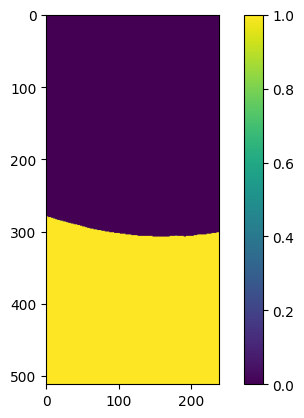

In [ ]:
plt.imshow(train_y_images[11,:,:, 0])
plt.colorbar()

(1169, 512, 240, 12)
train_y_masks.shape (1169, 512, 240, 12)


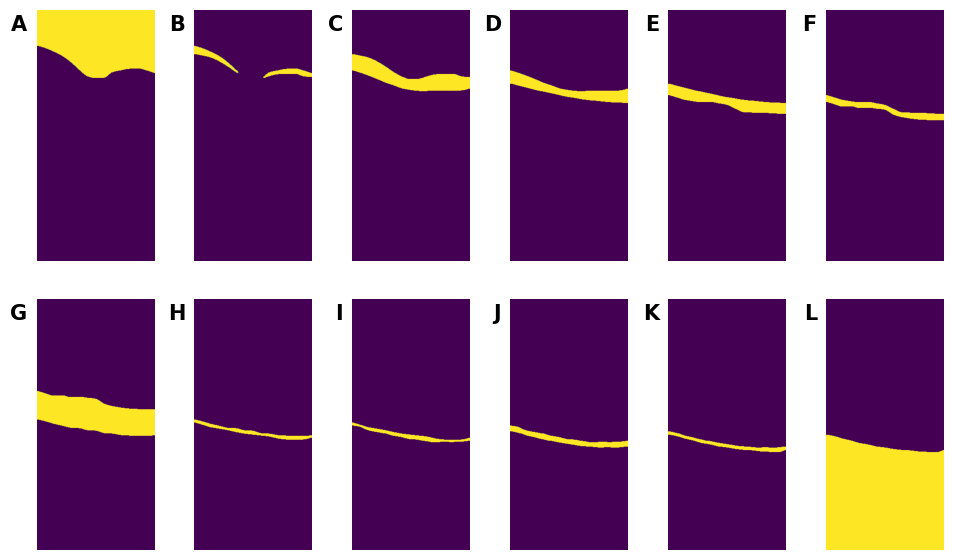

train_y_masks.shape (after processing) (1169, 512, 240)
<class 'numpy.ndarray'>


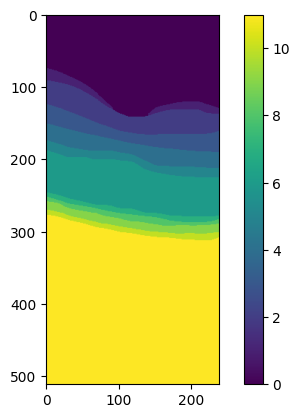

In [ ]:
# extra processing for masks, reducing number of masks to 1 mask per img
n_total_masks = train_y_images.shape[0]
n_samples = n_total_masks // 12

train_y_masks = np.zeros((n_samples,SIZE_Y,SIZE_X,12))
print(train_y_masks.shape)

for i in range(12):
    x = np.arange(i,n_samples*12,12)
    train_y_masks[:, :, :, i] = train_y_images[x,:,:,0]

print("train_y_masks.shape", train_y_masks.shape)

# visualise all 7 masks
#class_names = [
    #"Choroid",
    #"GCL + IPL",
    #"INL + OPL",
    #"ONL + ELM",
    #"PR + RPE",
    #"RNFL",
    #"Background"
#]

class_names = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L"
]

fig, axs = plt.subplots(2, 6, figsize=(18, 6))
axs = axs.ravel()

for i in range(12):
    axs[i].imshow(train_y_masks[8, :, :, i])
    axs[i].axis('off')

    # Panel label (A, B, C...) — unchanged
    axs[i].text(-0.08, 0.9, chr(65 + i),
                transform=axs[i].transAxes,
                fontsize=15, fontweight='bold',
                ha='right', va='bottom')


# refined but simple spacing (paper-like, not over-tight)
plt.subplots_adjust(
    left=0.03, right=0.55,
    top=0.95, bottom=0.05,
    wspace=0.08, hspace=0.15
)

plt.savefig("12masks.svg", bbox_inches='tight')
plt.show()

train_y_masks = np.argmax(train_y_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("train_y_masks.shape (after processing)",train_y_masks.shape)

print(type(train_y_masks))
plt.imshow(train_y_masks[8])
plt.colorbar()

# visualise with names

fig, axs = plt.subplots(2, 6, figsize=(18, 6))
for i in range(12):
    row = i // 6
    col = i % 6
    
    axs[row, col].imshow(train_y_masks[5, :, :, i])
    axs[row, col].set_title(f"{class_names[i]}", fontsize=14)
    axs[row, col].axis('off')

#Adjust spacing
plt.subplots_adjust(left=0.01, right=0.4, top=0.9, bottom=0.1, wspace=0.02, hspace=0.15)

plt.show()

train_y_masks = np.argmax(train_y_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("train_y_masks.shape (after processing)",train_y_masks.shape)

print(type(train_y_masks))
plt.imshow(train_y_masks[8])
plt.colorbar()

In [ ]:
# Split dataset into 70% train, 15% validation, and 15% completely unseen test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(train_x_images, train_y_masks, test_size = 0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size = 0.17647, shuffle=False)

print("X_train shape: ", X_train.shape)
print("X_val shape:     ", X_val.shape)
print("X_test shape:   ", X_test.shape)


X_train shape:  (817, 512, 240, 1)
X_val shape:      (176, 512, 240, 1)
X_test shape:    (176, 512, 240, 1)


In [ ]:
# Convert label masks to one-hot encoding
y_train_tensor = torch.as_tensor(y_train, dtype=torch.long)
y_train_cat = F.one_hot(y_train_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

y_val_tensor = torch.as_tensor(y_val, dtype=torch.long)
y_val_cat = F.one_hot(y_val_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

y_test_tensor = torch.as_tensor(y_test, dtype=torch.long)
y_test_cat = F.one_hot(y_test_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

# Convert images to tensors and permute
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: torch.Size([817, 1, 512, 240])
X_val shape: torch.Size([176, 1, 512, 240])
X_test shape: torch.Size([176, 1, 512, 240])


In [ ]:
# Define augmentation and dataset

train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),
    #A.VerticalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.15,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT,
        p=0.7
    ),

    #A.Affine(
        #scale=(0.8, 1.2),
        #translate_percent=0.1,
        #p=0.5
    #),

    #A.ElasticTransform(
        #alpha=120,
        #sigma=120 * 0.05,
        #alpha_affine=120 * 0.03,
        #p=0.5
    #),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    #A.GaussNoise(
        #var_limit=(10, 50),
        #p=0.3
    #),

], additional_targets={'mask': 'mask'})

class OCTDataset(Dataset):
    def __init__(self, images, masks_cat, transform=None):
        self.images = images
        self.masks_cat = masks_cat
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = (self.images[idx]).permute(1, 2, 0).numpy()   # (H, W, C) for albumentations
        mask = (self.masks_cat[idx]).permute(1, 2, 0).numpy()

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # convert back to tensor (C, H, W)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).permute(2, 0, 1)

        return image, mask

C:\Users\sandi\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# dataloader helps with loading data in batches, and iterations
train_dataset = OCTDataset(X_train, y_train_cat, transform=train_transform)
val_dataset   = OCTDataset(X_val, y_val_cat, transform=None)
test_dataset  = OCTDataset(X_test, y_test_cat, transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for images, masks in train_loader:
    print(images.shape, masks.shape)
    break


torch.Size([16, 1, 512, 240]) torch.Size([16, 12, 512, 240])


In [ ]:
# Calculating the weights for each class

pixel_counts = torch.zeros(n_classes)

for i in range(len(y_train_tensor)):
    uniq, counts = torch.unique(y_train_tensor[i], return_counts=True)
    for u, c in zip(uniq, counts):
        pixel_counts[u] += c

class_weights = 1.0 / (pixel_counts + 1e-6)   #inversing so that thinner layer = more weight
class_weights = class_weights / class_weights.mean()   #Normalising the weights
class_weights = class_weights.to(device)
print("Class Weights", class_weights)

Class Weights tensor([0.1076, 1.0595, 0.5489, 0.7671, 0.7074, 1.0569, 0.2955, 2.2823, 1.8722,
        1.4456, 1.7905, 0.0665], device='cuda:0')


In [ ]:
# Defining the loss functions

def tversky_loss(preds, targets, class_weights=None, alpha=0.7, beta=0.3, smooth=1e-6):
    preds = torch.softmax(preds, dim=1)

    TP = (preds * targets).sum(dim=(2, 3))
    FP = ((1 - targets) * preds).sum(dim=(2, 3))
    FN = (targets * (1 - preds)).sum(dim=(2, 3))

    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    tversky_loss = 1 - tversky  # (B, C)

    if class_weights is not None:
        class_weights = class_weights.to(preds.device).unsqueeze(0)  # (1, C)
        tversky_loss = tversky_loss * class_weights
        return (tversky_loss.sum(dim=1) / class_weights.sum()).mean()

    return tversky_loss.mean()

criterion_ce = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)

def dice_loss_per_class(preds, targets, class_weights=None):
    preds = torch.softmax(preds, dim=1)
    smooth = 1e-6

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice_score = (2. * intersection + smooth) / (union + smooth)
    dice_loss = 1 - dice_score  # (B, C)

    if class_weights is not None:
        class_weights = class_weights.to(preds.device).unsqueeze(0)
        dice_loss = dice_loss * class_weights
        return (dice_loss.sum(dim=1) / class_weights.sum()).mean()

    return dice_loss.mean()

def combined_loss(preds, targets):
    ce = criterion_ce(preds, torch.argmax(targets, dim=1))
    tv = tversky_loss(preds, targets)
    dl = dice_loss_per_class(preds, targets)
    return 0.1 * ce + 0.6 * tv + 0.3 * dl


In [ ]:
# Dice Score and accuracy calculation
def dice_score(preds, targets, smooth=1e-6):

    preds = torch.argmax(preds, dim=1)
    targets = torch.argmax(targets, dim=1)
    dice = 0.0

    for c in range(n_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice_c = (2 * intersection + smooth) / (union + smooth)
        dice += dice_c
    return dice / n_classes  # mean dice over classes

def pixel_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    targets = torch.argmax(targets, dim=1)
    correct = (preds == targets).float()

    return correct.mean().item()

In [ ]:
# load model
model = multi_unet_model1(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)   # after every 20 epochs, lr will be reduced by half

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'train_dice': [],
           'val_loss': [], 'val_acc': [], 'val_dice': []}

num_train = X_train.shape[0]
num_test = X_test.shape[0]

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    train_dice = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += pixel_accuracy(outputs, masks)
        train_dice += dice_score(outputs, masks)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_dice /= len(train_loader)

    scheduler.step()

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()
            val_acc += pixel_accuracy(outputs, masks)
            val_dice += dice_score(outputs, masks)

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_dice /= len(val_loader)

    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_dice'].append(val_dice)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr} | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Dice: {val_dice:.4f}")

Epoch [1/50] | LR: 0.001 | Train Loss: 1.0911 | Acc: 0.3126 | Dice: 0.1563 | Val Loss: 0.9848 | Acc: 0.5301 | Dice: 0.2913
Epoch [2/50] | LR: 0.001 | Train Loss: 0.9315 | Acc: 0.5934 | Dice: 0.3971 | Val Loss: 0.7629 | Acc: 0.8151 | Dice: 0.5845
Epoch [3/50] | LR: 0.001 | Train Loss: 0.7453 | Acc: 0.7946 | Dice: 0.6174 | Val Loss: 0.5765 | Acc: 0.9224 | Dice: 0.7934
Epoch [4/50] | LR: 0.001 | Train Loss: 0.5769 | Acc: 0.8959 | Dice: 0.7824 | Val Loss: 0.4830 | Acc: 0.9426 | Dice: 0.8294
Epoch [5/50] | LR: 0.001 | Train Loss: 0.5025 | Acc: 0.9268 | Dice: 0.8287 | Val Loss: 0.4434 | Acc: 0.9474 | Dice: 0.8479
Epoch [6/50] | LR: 0.001 | Train Loss: 0.4716 | Acc: 0.9368 | Dice: 0.8460 | Val Loss: 0.4681 | Acc: 0.9420 | Dice: 0.8261
Epoch [7/50] | LR: 0.001 | Train Loss: 0.4464 | Acc: 0.9467 | Dice: 0.8580 | Val Loss: 0.4271 | Acc: 0.9517 | Dice: 0.8531
Epoch [8/50] | LR: 0.001 | Train Loss: 0.4315 | Acc: 0.9501 | Dice: 0.8662 | Val Loss: 0.4169 | Acc: 0.9526 | Dice: 0.8595
Epoch [9/50] | L

In [1]:
MODEL_SAVE_PATH = r'D:\auto12_cirrus_best_tta.pth'

torch.save(model.state_dict(), MODEL_SAVE_PATH)

NameError: name 'torch' is not defined

In [ ]:
# -----------------------
# Reproducibility
# -----------------------
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
def tta_inference(model, images):
    """
    Applies TTA (Horizontal Flip + Left/Right Shifts) and averages logits.
    Vertical flips are purposefully removed as they break the structural properties of retinal OCTs.
    """

    # Pass 1: Original
    outputs = model(images)

    # Pass 2: Horizontal flip
    hflip = torch.flip(images, dims=[3])
    outputs_h = model(hflip)
    outputs_h = torch.flip(outputs_h, dims=[3])

    # Pass 3: Shift Right by 2 pixels
    images_shift_r = torch.roll(images, shifts=2, dims=3)
    outputs_r = model(images_shift_r)
    outputs_r = torch.roll(outputs_r, shifts=-2, dims=3)

    # Pass 4: Shift Left by 2 pixels
    images_shift_l = torch.roll(images, shifts=-2, dims=3)
    outputs_l = model(images_shift_l)
    outputs_l = torch.roll(outputs_l, shifts=2, dims=3)

    # Average logits
    outputs_mean = (outputs + outputs_h + outputs_r + outputs_l) / 4.0

    return outputs_mean


In [ ]:
test_acc = 0.0
test_dice = 0.0

test_acc_tta = 0.0
test_dice_tta = 0.0

model.eval()

with torch.no_grad():
    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        # =========================
        # NO TTA
        # =========================
        outputs = model(images)

        test_acc += pixel_accuracy(outputs, masks)
        test_dice += dice_score(outputs, masks)

        # =========================
        # WITH TTA
        # =========================
        outputs_tta = tta_inference(model, images)

        test_acc_tta += pixel_accuracy(outputs_tta, masks)
        test_dice_tta += dice_score(outputs_tta, masks)


# Average results
test_acc /= len(test_loader)
test_dice /= len(test_loader)

test_acc_tta /= len(test_loader)
test_dice_tta /= len(test_loader)

print("\n===== FINAL TEST RESULTS =====")
print(f"No TTA  -> Acc: {test_acc:.4f}, Dice: {test_dice:.4f}")
print(f"With TTA-> Acc: {test_acc_tta:.4f}, Dice: {test_dice_tta:.4f}")

improvement = test_dice_tta - test_dice
print(f"\nDice Improvement from TTA: {improvement:.4f}")



===== FINAL TEST RESULTS =====
No TTA  -> Acc: 0.9700, Dice: 0.9038
With TTA-> Acc: 0.9699, Dice: 0.9038

Dice Improvement from TTA: 0.0000


ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

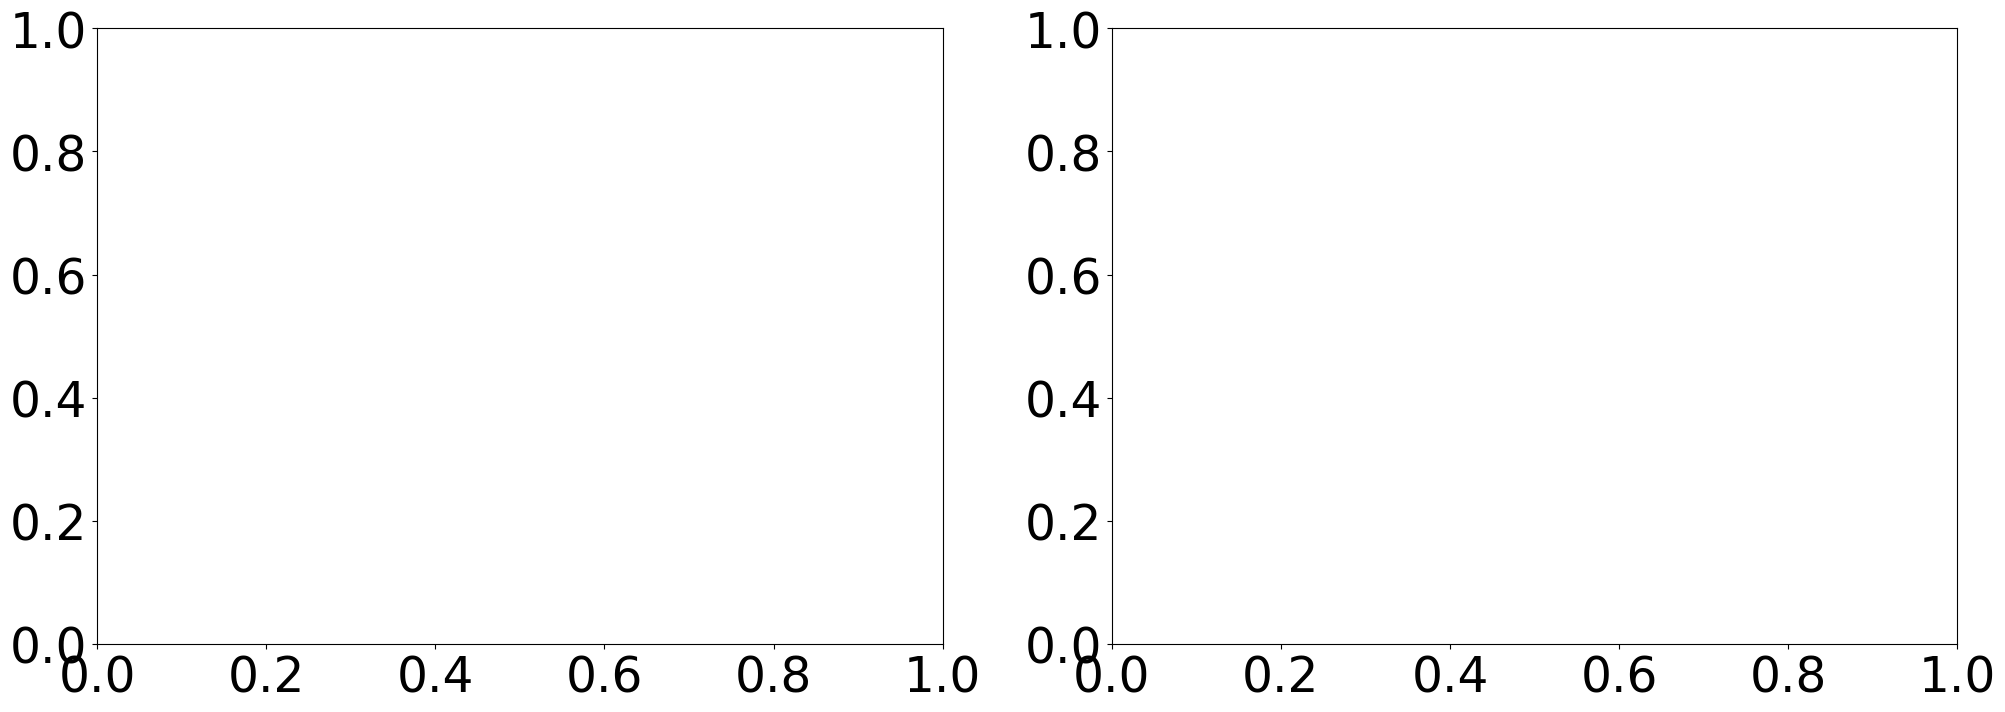

In [ ]:
# --- Fixed font size ---
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 40,
    'axes.labelsize': 34,
    'xtick.labelsize': 35,
    'ytick.labelsize': 35,
    'legend.fontsize': 30
})

epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Left plot: Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=5)
axes[0].plot(epochs, history['val_loss'], label='Val Loss', linewidth=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_ylim(bottom=0)
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Right plot: Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train Accuracy', linewidth=5)
axes[1].plot(epochs, history['val_acc'], label='Val Accuracy', linewidth=5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(bottom=0)
axes[1].legend(loc='lower right')
axes[1].grid(True)

# --- Add OUTSIDE panel labels (A, B) ---
fig.text(0.02, 0.95, 'A', fontsize=40, fontweight='bold', va='top', ha='left')
fig.text(0.51, 0.95, 'B', fontsize=40, fontweight='bold', va='top', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.92], w_pad=3)  # leave space for top labels
plt.savefig("graph_tta.svg", bbox_inches='tight')
plt.show()

In [ ]:
def dice_per_class(y_true, y_pred, num_classes):
    assert y_true.shape == y_pred.shape, f"Shapes must match: {y_true.shape} vs {y_pred.shape}"
    dices = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).float()
        y_pred_cls = (y_pred == cls).float()

        intersection = (y_true_cls * y_pred_cls).sum()
        union = y_true_cls.sum() + y_pred_cls.sum()
        dice = (2 * intersection) / (union + 1e-6)
        dices.append(dice.item())
    mean_dice = sum(dices) / num_classes
    return mean_dice, dices

# Convert outputs to class indices
#y_pred = torch.argmax(outputs, dim=1)  # (B, H, W)
y_pred = torch.argmax(outputs_tta, dim=1)  # (B, H, W)

y_true = torch.argmax(masks, dim=1)                   # (B, H, W) already integer labels

# Compute Dice
mean_dice_val, class_dice_list = dice_per_class(y_true, y_pred, num_classes=12)

# Class names for 12 retinal layers
class_names = [
    "Background",
    "RNFL",
    "GCL",
    "IPL",
    "INL",
    "OPL",
    "ONL+ELM",
    "IS/OS",
    "EZ",
    "POS",
    "RPE",
    "Choroid"
]

print(f"Mean Dice: {mean_dice_val:.4f}")
for name, dice in zip(class_names, class_dice_list):
    print(f"{name} Dice: {dice:.4f}")

Mean Dice: 0.9147
Background Dice: 0.9958
RNFL Dice: 0.9051
GCL Dice: 0.9302
IPL Dice: 0.9076
INL Dice: 0.9370
OPL Dice: 0.9003
ONL+ELM Dice: 0.9669
IS/OS Dice: 0.8580
EZ Dice: 0.8545
POS Dice: 0.8431
RPE Dice: 0.8805
Choroid Dice: 0.9973


In [ ]:
# Pick test image
test_img_number = 10
test_img = X_test[test_img_number]      # (1, H, W)
ground_truth_img = y_test_tensor[test_img_number]   # (H, W), already class indices

# Convert to torch tensor and add batch dimension for model
test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


# Make prediction
model.eval()
with torch.no_grad():
    output = model(test_img_input)           # (1, num_classes, H, W)
    prediction = torch.argmax(output, dim=1)  # (1, H, W)

    output_tta = tta_inference(model, test_img_input)
    prediction_tta = torch.argmax(output_tta, dim=1)

predicted_img = prediction[0].cpu().numpy()  # (H, W)
predicted_img_tta = prediction_tta[0].cpu().numpy()  # (H, W)


C:\Users\sandi\AppData\Local\Temp\ipykernel_20048\3882636233.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


In [ ]:
# Original size and crop
orig_h, orig_w = 1024, 245  # original pixels
orig_mm_h, orig_mm_w = 2, 3 # mm

# Cropped size
crop_h, crop_w = 512, 240   # after your cropping
# Pixel size in mm
pixel_size_x = orig_mm_w / orig_w   # mm per pixel in x
pixel_size_y = orig_mm_h / orig_h   # mm per pixel in y

print (pixel_size_x)
print (pixel_size_y)


0.012244897959183673
0.001953125


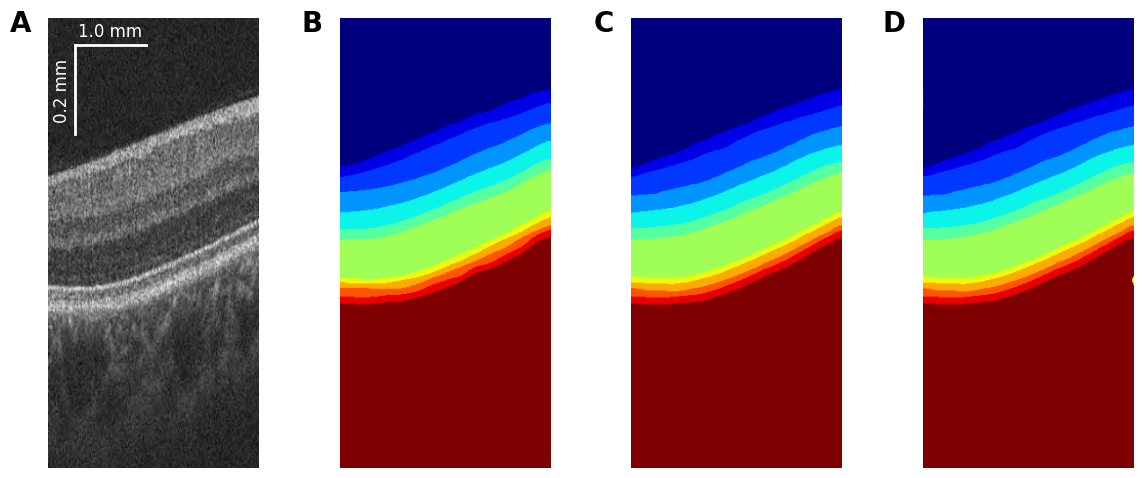

In [ ]:
# Compute pixels for scale
scale_x_mm = 1.0
scale_y_mm = 0.2
scale_x_px = int(scale_x_mm / pixel_size_x)
scale_y_px = int(scale_y_mm / pixel_size_y)

x0, y0 = 30, 30

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# --- A: Test image ---
ax[0].imshow(test_img[0], cmap='gray')
ax[0].axis('off')

ax[0].add_line(plt.Line2D([x0, x0 + scale_x_px], [y0, y0], color='white', linewidth=2))
ax[0].add_line(plt.Line2D([x0, x0], [y0, y0 + scale_y_px], color='white', linewidth=2))

ax[0].text(x0 + scale_x_px//2, y0 - 5, f'{scale_x_mm} mm',
           color='white', ha='center', va='bottom', fontsize=12)
ax[0].text(x0 - 5, y0 + scale_y_px//2, f'{scale_y_mm} mm',
           color='white', ha='right', va='center', fontsize=12, rotation=90)

# --- B ---
ax[1].imshow(ground_truth_img, cmap='jet')
ax[1].axis('off')

# --- C ---
ax[2].imshow(predicted_img, cmap='jet')
ax[2].axis('off')

# --- D ---
ax[3].imshow(predicted_img_tta, cmap='jet')
ax[3].axis('off')

# ---- LABELS ----
labels = ['A', 'B', 'C', 'D']

for label, a in zip(labels, ax):
    a.text(
        -0.08, 1.02, label,
        transform=a.transAxes,
        fontsize=20,
        fontweight='bold',
        ha='right',
        va='top'
    )

# ---- TIGHT SPACING ----
plt.subplots_adjust(
    wspace=0.02,
    hspace=0.0,
    left=0.02,
    right=0.6,
    top=0.95,
    bottom=0.05
)

plt.savefig("pred_tta.svg", bbox_inches='tight')
plt.show()

pred_images.shape (5, 512, 320, 1)
<class 'numpy.ndarray'>


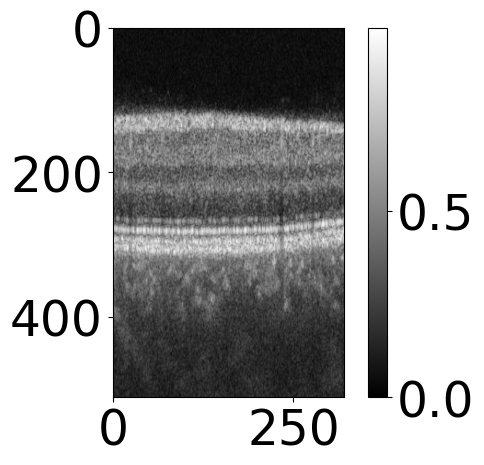

In [ ]:
# Path to test images
x_plex_path = r"D:\Segmentation\output_plex\images"
y_plex_path = r"D:\Segmentation\output_plex\masks"

# prepare training x (original) images
pred_x_images = []

for directory_path in glob.glob(x_plex_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (320, 512))
        pred_x_images.append(img)

pred_x_images = np.array(pred_x_images, dtype=np.float32)   #using float32 for PyTorch
pred_x_images = pred_x_images / 255.0
pred_x_images = np.expand_dims(pred_x_images, axis=-1)

print("pred_images.shape", pred_x_images.shape)
print(type(pred_x_images))

plt.imshow(pred_x_images[0], cmap='gray')
plt.colorbar()


In [ ]:
# loading and checking y (masks) data
pred_y_images = []

for directory_path in glob.glob(y_plex_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (320, 512))
        pred_y_images.append(img)

pred_y_images = np.array(pred_y_images, dtype=np.float32)   #using float32 for PyTorch
pred_y_images = pred_y_images / 255.0
pred_y_images = np.expand_dims(pred_y_images, axis=-1)

print("pred_masks.shape", pred_y_images.shape)
print(type(pred_y_images))

# extra processing for masks, reducing number of masks to 1 mask per img
n_total_masks = pred_y_images.shape[0]
n_samples = n_total_masks // 12

pred_y_masks = np.zeros((n_samples,512,320,12))
print(pred_y_masks.shape)

for i in range(12):
    x = np.arange(i,n_samples*12,12)
    pred_y_masks[:, :, :, i] = pred_y_images[x,:,:,0]

#visualise all 12 masks
class_names = [
    "Background",
    "RNFL",
    "GCL",
    "IPL",
    "INL",
    "OPL",
    "ONL+ELM",
    "IS/OS",
    "EZ",
    "POS",
    "RPE",
    "Choroid"
]

pred_masks.shape (60, 512, 320, 1)
<class 'numpy.ndarray'>
(5, 512, 320, 12)


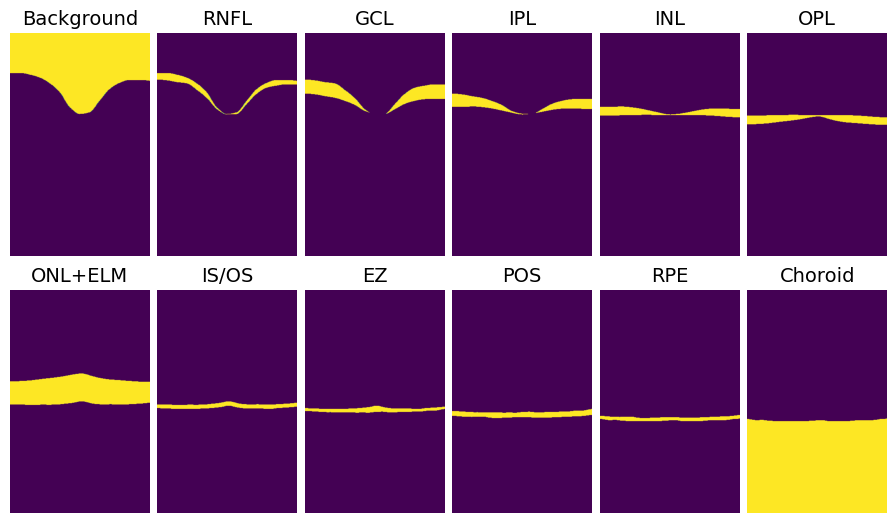

In [ ]:
fig, axs = plt.subplots(2, 6, figsize=(18, 6))
for i in range(12):
    row = i // 6
    col = i % 6

    axs[row, col].imshow(pred_y_masks[2, :, :, i])
    axs[row, col].set_title(f"{class_names[i]}", fontsize=14)
    axs[row, col].axis('off')

# Adjust spacing
plt.subplots_adjust(left=0.01, right=0.5, top=0.9, bottom=0.1, wspace=0.02, hspace=0.15)

plt.show()

pred_y_masks.shape (after processing) (5, 512, 320)
<class 'numpy.ndarray'>


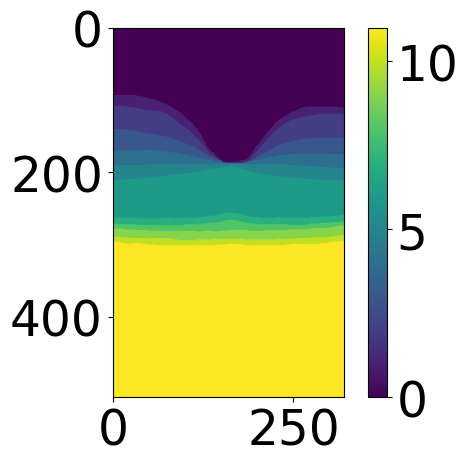

In [ ]:
pred_y_masks = np.argmax(pred_y_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("pred_y_masks.shape (after processing)",pred_y_masks.shape)

print(type(pred_y_masks))
plt.imshow(pred_y_masks[2])
plt.colorbar()

In [ ]:
# Convert masks to tensors and one-hot
y_pred_tensor = torch.as_tensor(pred_y_masks, dtype=torch.long)
y_pred_cat = F.one_hot(y_pred_tensor, num_classes=n_classes).permute(0, 3, 1, 2).float()

# Convert images to tensors and permute
X_pred = torch.tensor(pred_x_images, dtype=torch.float32).permute(0, 3, 1, 2)

print(f"X_pred shape: {X_pred.shape}")
print(f"y_pred_cat shape: {y_pred_cat.shape}")

X_pred shape: torch.Size([5, 1, 512, 320])
y_pred_cat shape: torch.Size([5, 12, 512, 320])


In [ ]:
# Pick test image
test_img_number = 2
test_img = X_pred[test_img_number]      # (1, H, W)
ground_truth_img = y_pred_tensor[test_img_number]   # (H, W), already class indices

# Convert to torch tensor and add batch dimension for model
test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


# Make prediction
model.eval()
with torch.no_grad():
    output = model(test_img_input)           # (1, num_classes, H, W)
    prediction = torch.argmax(output, dim=1)  # (1, H, W)

predicted_img = prediction[0].cpu().numpy()  # (H, W)

C:\Users\sandi\AppData\Local\Temp\ipykernel_20048\3021297936.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_img_input = torch.tensor(test_img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, H, W)


In [ ]:
# Original size and crop
orig_h, orig_w = 1536, 300  # original pixels
orig_mm_h, orig_mm_w = 3, 3 # mm

# Cropped size
crop_h, resize_w = 512, 320   # after your cropping

# Pixel size in mm
pixel_size_x = orig_mm_w / orig_w   # mm per pixel in x
pixel_size_y = orig_mm_h / orig_h   # mm per pixel in y

print (pixel_size_x)
print (pixel_size_y)


0.01
0.001953125


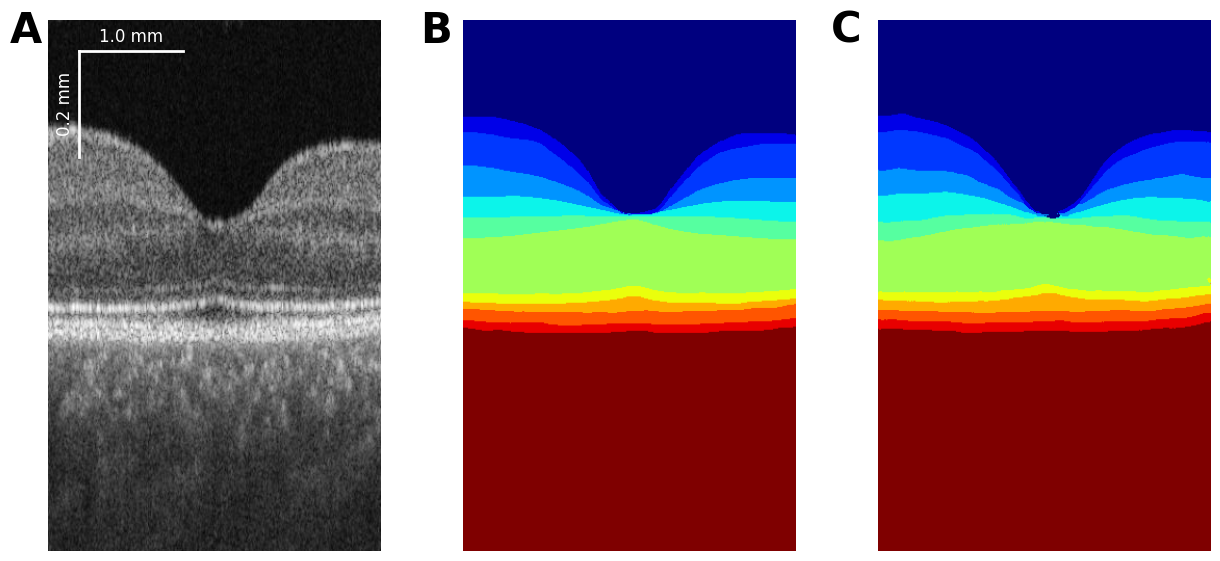

In [ ]:
# Compute pixels for scale
scale_x_mm = 1.0
scale_y_mm = 0.2
scale_x_px = int(scale_x_mm / pixel_size_x)
scale_y_px = int(scale_y_mm / pixel_size_y)

x0, y0 = 30, 30

fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# --- A: Test image ---
ax[0].imshow(test_img[0], cmap='gray')
ax[0].axis('off')

ax[0].add_line(plt.Line2D([x0, x0 + scale_x_px], [y0, y0], color='white', linewidth=2))
ax[0].add_line(plt.Line2D([x0, x0], [y0, y0 + scale_y_px], color='white', linewidth=2))

ax[0].text(x0 + scale_x_px//2, y0 - 5, f'{scale_x_mm} mm',
           color='white', ha='center', va='bottom', fontsize=12)
ax[0].text(x0 - 5, y0 + scale_y_px//2, f'{scale_y_mm} mm',
           color='white', ha='right', va='center', fontsize=12, rotation=90)

# --- B ---
ax[1].imshow(ground_truth_img, cmap='jet')
ax[1].axis('off')

# --- C ---
ax[2].imshow(predicted_img, cmap='jet')
ax[2].axis('off')

# ---- PERFECTLY ALIGNED OUTSIDE LABELS ----
for i, label in enumerate(['A', 'B', 'C']):
    pos = ax[i].get_position()
    fig.text(
        pos.x0 - 0.025, pos.y1 - 0.04, label,
        fontsize=30, fontweight='bold',
        ha='left', va='bottom'
    )

plt.subplots_adjust(wspace=0.25)

plt.savefig("auto_pred_12_plex_bad.svg", bbox_inches='tight')
plt.show()

In [ ]:
# calculate dice score of single prediction
def dice_per_class(y_true, y_pred, num_classes):
    dices = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).float()
        y_pred_cls = (y_pred == cls).float()

        intersection = (y_true_cls * y_pred_cls).sum()
        union = y_true_cls.sum() + y_pred_cls.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        dices.append(dice.item())

    mean_dice = sum(dices) / num_classes
    return mean_dice, dices

# Number of classes
num_classes = 12

# Convert ground truth to torch tensor if needed
if not isinstance(ground_truth_img, torch.Tensor):
    y_true = torch.tensor(ground_truth_img, dtype=torch.int64)
else:
    y_true = ground_truth_img

# Convert predicted mask to torch tensor
if not isinstance(predicted_img, torch.Tensor):
    y_pred = torch.tensor(predicted_img, dtype=torch.int64)
else:
    y_pred = predicted_img

# Compute Dice scores
mean_dice_val, class_dice_list = dice_per_class(y_true, y_pred, num_classes=num_classes)

# Class names
class_names = [
    "Background",
    "RNFL",
    "GCL",
    "IPL",
    "INL",
    "OPL",
    "ONL+ELM",
    "IS/OS",
    "EZ",
    "POS",
    "RPE",
    "Choroid"
]

print(f"Mean Dice: {mean_dice_val:.4f}")
for name, dice in zip(class_names, class_dice_list):
    print(f"{name} Dice: {dice:.4f}")

Mean Dice: 0.8740
Background Dice: 0.9928
RNFL Dice: 0.7962
GCL Dice: 0.8961
IPL Dice: 0.8399
INL Dice: 0.8631
OPL Dice: 0.8559
ONL+ELM Dice: 0.9647
IS/OS Dice: 0.7559
EZ Dice: 0.8389
POS Dice: 0.8823
RPE Dice: 0.8058
Choroid Dice: 0.9970


In [ ]:
# Path to disease prediction images
pred_path = r"D:\Segmentation\CIRRUS_DISEASE_MASKS\images"

# Capture test images as a list
pred_images = []

for img_path in glob.glob(os.path.join(pred_path, "*.png")):
    img = cv2.imread(img_path, 0)
    img = cv2.resize(img, (240, 512))                 # resize (W, H)
    pred_images.append(img)

# Convert list to numpy array
pred_images = np.array(pred_images)  # (N, H, W)

# Add channel dimension
pred_images = np.expand_dims(pred_images, axis=3)  # (N, H, W, 1)

# Normalize to [0,1]
pred_images = pred_images / 255.0

# Convert to torch tensor with channels first
pred_images_tensor = torch.tensor(pred_images, dtype=torch.float32).permute(0, 3, 1, 2)  # (N, 1, H, W)

print("pred images shape (PyTorch):", pred_images_tensor.shape)


pred images shape (PyTorch): torch.Size([51, 1, 512, 240])


true_masks.shape (612, 512, 240, 1)
<class 'numpy.ndarray'>
(51, 512, 240, 12)


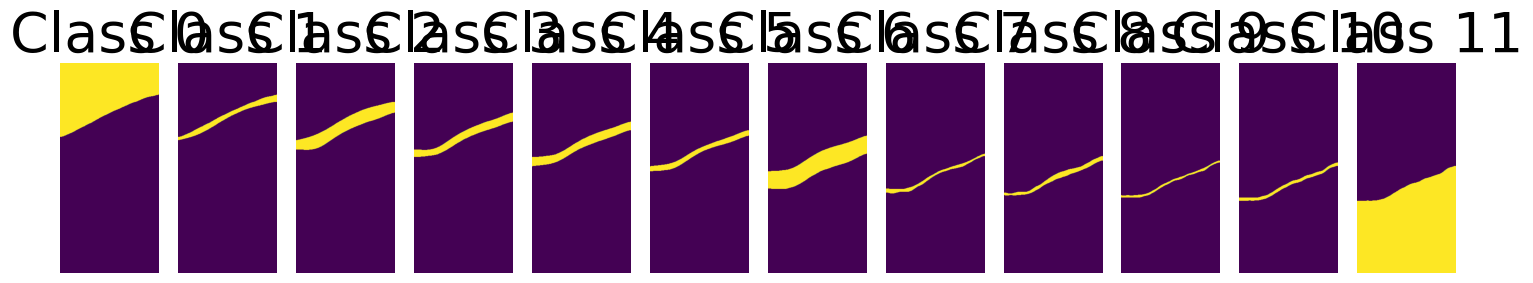

true_masks.shape (after processing) (51, 512, 240)


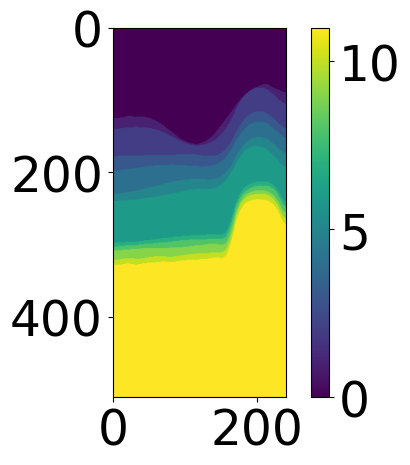

In [ ]:
#loading and checking ground truth data

true_path = r"D:\Segmentation\CIRRUS_DISEASE_MASKS\masks"
true_images = []

for directory_path in glob.glob(true_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.png")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (240, 512))
        true_images.append(img)

true_images = np.array(true_images, dtype=np.float32)   #using float32 for PyTorch
true_images = true_images / 255.0
true_images = np.expand_dims(true_images, axis=-1)

print("true_masks.shape", true_images.shape)
print(type(true_images))

# extra processing for masks, reducing number of masks to 1 mask per img
n_total_masks = true_images.shape[0]
n_samples = n_total_masks // 12

true_masks = np.zeros((n_samples,512,240,12))
print(true_masks.shape)

for i in range(12):
    x = np.arange(i,n_samples*12,12)
    true_masks[:, :, :, i] = true_images[x,:,:,0]

#visualise all 12 masks
fig, axs = plt.subplots(1, 12, figsize=(18, 3))
for i in range(12):
    axs[i].imshow(true_masks[0,:,:,i])
    axs[i].set_title(f"Class {i}")
    axs[i].axis('off')
plt.show()

true_masks = np.argmax(true_masks, axis=-1)  # needed for later classification, if not will only show binary classes
print("true_masks.shape (after processing)",true_masks.shape)

plt.imshow(true_masks[30])
plt.colorbar()


In [ ]:
# Select test image
pred_idx = 30

pred1 = pred_images_tensor[pred_idx]           # shape: (C, H, W)
print("Original pred image shape:", pred1.shape)
ground_truth = true_masks[pred_idx]  # one-hot (C, H, W)

# Add batch dimension and move to device
pred_img_tensor = pred1.unsqueeze(0).to(device)  # shape: (1, C, H, W)
print("Input to model shape:", pred_img_tensor.shape)

# Prediction
model.eval()
with torch.no_grad():
    output = model(pred_img_tensor)              # shape: (1, num_classes, H, W)
    predicted_img = torch.argmax(output, dim=1)  # shape: (1, H, W)

predicted_img = predicted_img[0].cpu().numpy()    # shape: (H, W)
print("Predicted image shape:", predicted_img.shape)



Original pred image shape: torch.Size([1, 512, 240])
Input to model shape: torch.Size([1, 1, 512, 240])
Predicted image shape: (512, 240)


In [ ]:
# Original size and crop
orig_h, orig_w = 1024, 245  # original pixels
orig_mm_h, orig_mm_w = 2, 3 # mm

# Cropped size
crop_h, resize_w = 512, 240   # after your cropping

# Pixel size in mm
pixel_size_x = orig_mm_w / orig_w   # mm per pixel in x
pixel_size_y = orig_mm_h / orig_h   # mm per pixel in y

print (pixel_size_x)
print (pixel_size_y)

0.012244897959183673
0.001953125


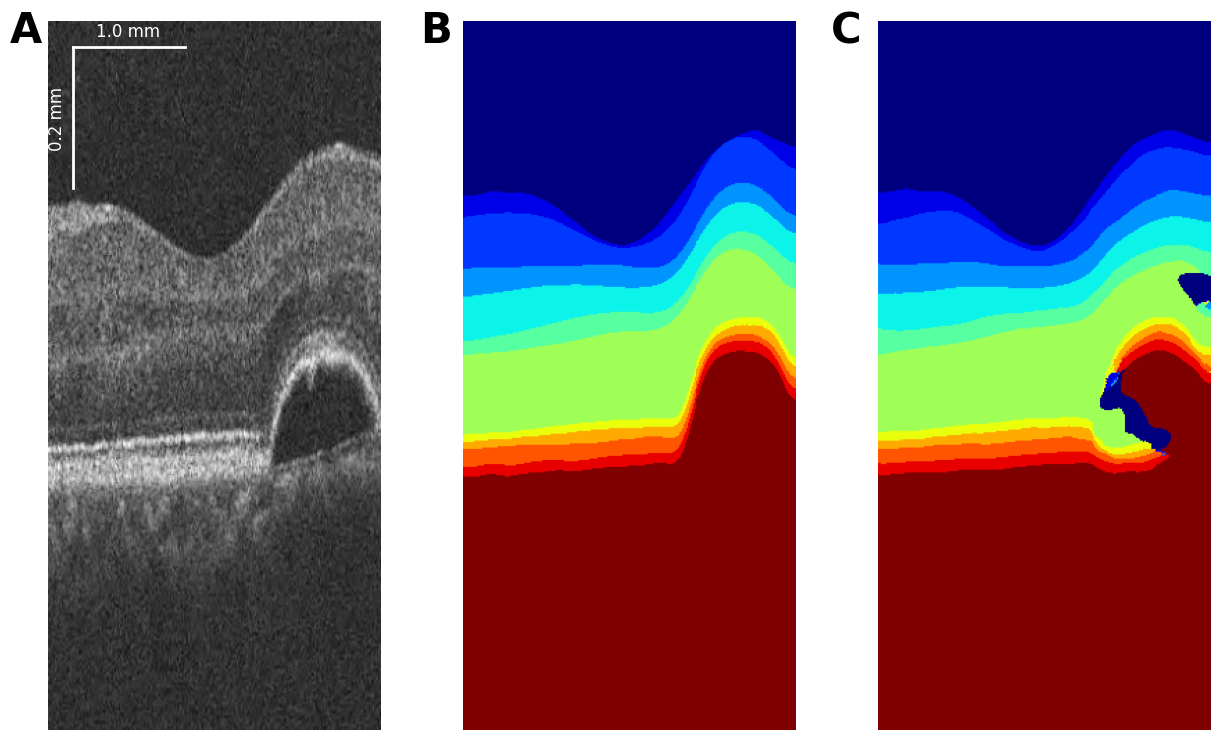

In [ ]:
# Compute pixels for scale
scale_x_mm = 1.0
scale_y_mm = 0.2
scale_x_px = int(scale_x_mm / pixel_size_x)
scale_y_px = int(scale_y_mm / pixel_size_y)

x0, y0 = 18, 18

fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# --- A: Test image ---
ax[0].imshow(pred1[0], cmap='gray')
ax[0].axis('off')

ax[0].add_line(plt.Line2D([x0, x0 + scale_x_px], [y0, y0], color='white', linewidth=2))
ax[0].add_line(plt.Line2D([x0, x0], [y0, y0 + scale_y_px], color='white', linewidth=2))

ax[0].text(x0 + scale_x_px//2, y0 - 5, f'{scale_x_mm} mm',
           color='white', ha='center', va='bottom', fontsize=12)
ax[0].text(x0 - 5, y0 + scale_y_px//2, f'{scale_y_mm} mm',
           color='white', ha='right', va='center', fontsize=12, rotation=90)

# --- B ---
ax[1].imshow(ground_truth, cmap='jet')
ax[1].axis('off')

# --- C ---
ax[2].imshow(predicted_img, cmap='jet')
ax[2].axis('off')

# ---- PERFECTLY ALIGNED OUTSIDE LABELS ----
for i, label in enumerate(['A', 'B', 'C']):
    pos = ax[i].get_position()
    fig.text(
        pos.x0 - 0.025, pos.y1 - 0.04, label,
        fontsize=30, fontweight='bold',
        ha='left', va='bottom'
    )

plt.subplots_adjust(wspace=0.25)

plt.savefig("auto_pred_12_disease_bad.svg", bbox_inches='tight')
plt.show()

In [ ]:
# calculate dice score of single prediction
def dice_per_class(y_true, y_pred, num_classes):
    dices = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).float()
        y_pred_cls = (y_pred == cls).float()

        intersection = (y_true_cls * y_pred_cls).sum()
        union = y_true_cls.sum() + y_pred_cls.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        dices.append(dice.item())

    mean_dice = sum(dices) / num_classes
    return mean_dice, dices

# Number of classes
num_classes = 12

# Convert ground truth to torch tensor if needed
if not isinstance(ground_truth, torch.Tensor):
    y_true = torch.tensor(ground_truth, dtype=torch.int64)
else:
    y_true = ground_truth

# Convert predicted mask to torch tensor
if not isinstance(predicted_img, torch.Tensor):
    y_pred = torch.tensor(predicted_img, dtype=torch.int64)
else:
    y_pred = predicted_img

# Compute Dice scores
mean_dice_val, class_dice_list = dice_per_class(y_true, y_pred, num_classes=num_classes)

# Class names
class_names = [
    "Background",
    "RNFL",
    "GCL",
    "IPL",
    "INL",
    "OPL",
    "ONL+ELM",
    "IS/OS",
    "EZ",
    "POS",
    "RPE",
    "Choroid"
]

print(f"Mean Dice: {mean_dice_val:.4f}")
for name, dice in zip(class_names, class_dice_list):
    print(f"{name} Dice: {dice:.4f}")

Mean Dice: 0.8116
Background Dice: 0.9722
RNFL Dice: 0.7242
GCL Dice: 0.8601
IPL Dice: 0.7618
INL Dice: 0.8258
OPL Dice: 0.6620
ONL+ELM Dice: 0.9137
IS/OS Dice: 0.7452
EZ Dice: 0.8026
POS Dice: 0.7933
RPE Dice: 0.7020
Choroid Dice: 0.9758
